In [33]:
# Standard Libraries
import math
import pickle
import random
import numpy as np

# Data Manipulation and Visualization
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
# matplotlib.use('Agg')  # For saving figures
import seaborn as sns
from sklearn.manifold import TSNE
from IPython.display import clear_output
from tqdm import tqdm

# Quantum Computing
import pennylane as qml

# PyTorch Libraries and Tools
import torch
import torch.nn as nn
from torch.autograd import Variable
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import DataLoader, TensorDataset

import importlib
from modules import QGAN, Discriminator, MINE  # 초기 import
importlib.reload(QGAN)  # 모듈 갱신
importlib.reload(Discriminator)  # 모듈 갱신
importlib.reload(MINE)  # 모듈 갱신

# Utility Functions
import kagglehub
from functools import reduce
import ndtest # 2D 분포 검정에 사용
from datetime import datetime
import os
import time
from modules.utils import convert_ipynb_to_html # 현재 html파일 저장을 위해 사용
import argparse
import json
from scipy.stats import ks_2samp

# for random forest
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

train_type = "InfoQGAN"
use_mine = True if train_type == "InfoQGAN" else False
data_type = "IRIS"

n_qubits = 6
code_qubits = 2
output_qubits = n_qubits
noise_qubits = n_qubits - code_qubits

n_features = n_qubits

n_layers = 20
BATCH_SIZE = 16
SEED = 0.7
epoch_num = 300

G_lr = 0.003
D_lr = 0.0003
M_lr = 0.003
coeff = 0.01

range_l = 0.15
range_r = 0.85

In [9]:
train_data_df = None

if data_type == "IRIS":
    path = kagglehub.dataset_download("uciml/iris")
    print("Path to dataset files:", path)
    csv_file = os.path.join(path, "iris.csv")
    raw_data_df = pd.read_csv(csv_file)
elif data_type == "WINE":
    path = kagglehub.dataset_download("yasserh/wine-quality-dataset")
    print("Path to dataset files:", path)
    csv_file = os.path.join(path, "WineQT.csv")
    raw_data_df = pd.read_csv(csv_file)

print(raw_data_df.shape, raw_data_df.columns)

Path to dataset files: C:\Users\minkyu\.cache\kagglehub\datasets\uciml\iris\versions\2
(150, 6) Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')


## Species 는 어떻게 처리할까
스칼라 하나로 처리해버리면 연속성 때문에 문제가 된다. 2차원이라면 되는데...
일단 species까지 drop하고 column 4개만 사용하자.

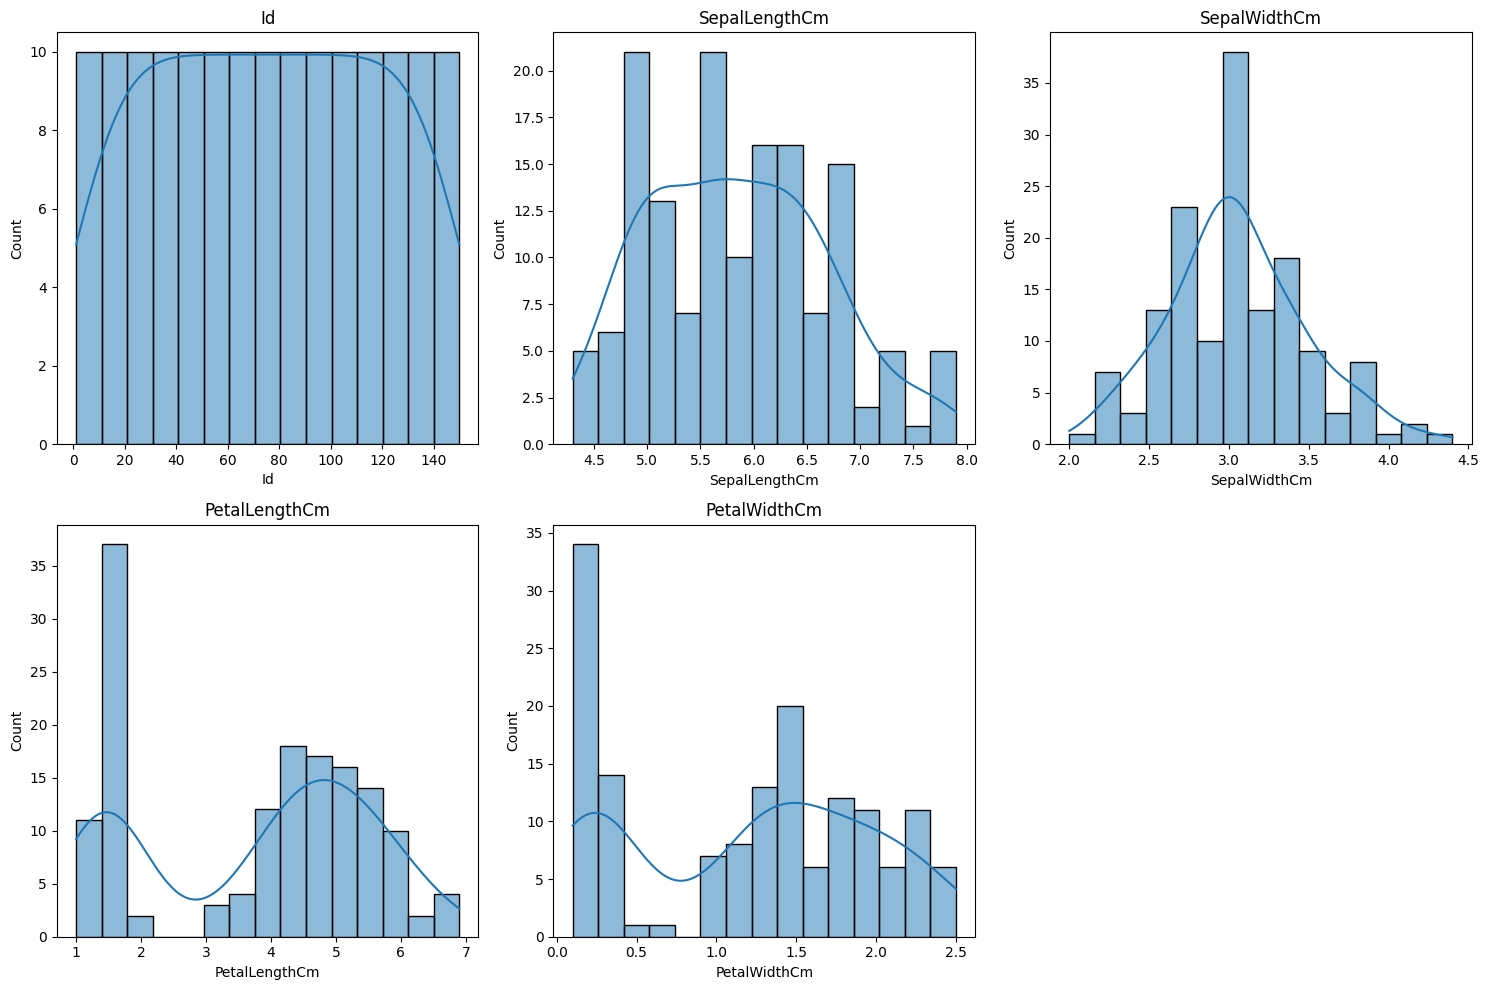

(150, 4)


In [19]:
# 수치형 변수 선택
numeric_cols = raw_data_df.select_dtypes(include=['float64', 'int64']).columns.tolist()

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(math.ceil(len(numeric_cols) / 3), 3, i + 1)
    sns.histplot(raw_data_df[col], kde=True, bins=15)
    plt.title(col)
plt.tight_layout()
plt.show()

train_data_df = raw_data_df[numeric_cols]
train_data_df = train_data_df.drop(columns=['Id'])
print(train_data_df.shape)

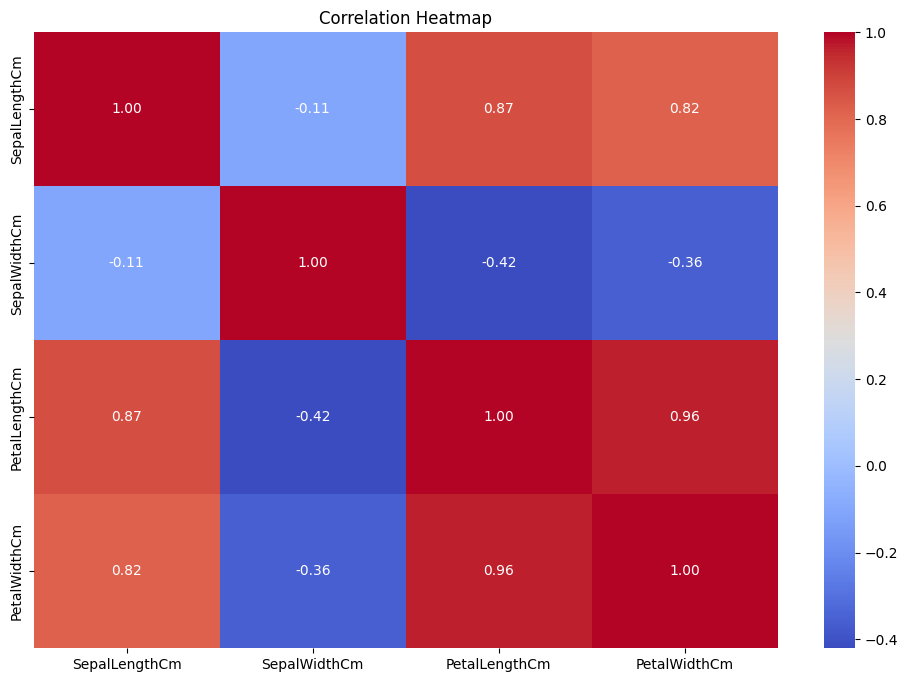

In [20]:
plt.figure(figsize=(12, 8))
corr = train_data_df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


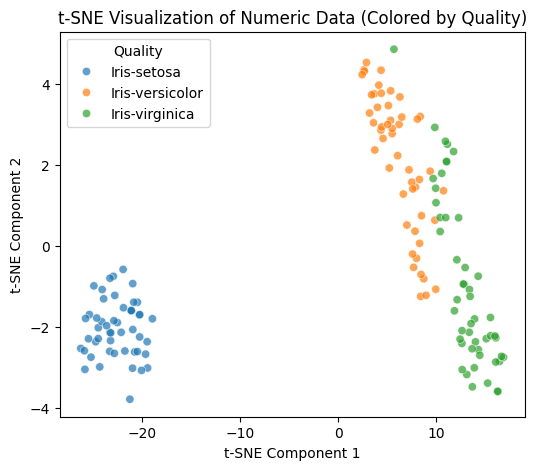

In [29]:
tsne = TSNE(n_components=2, random_state=42)
tsne_result = tsne.fit_transform(train_data_df.values)

# t-SNE 결과를 DataFrame으로 저장
tsne_df = pd.DataFrame(tsne_result, columns=['Component 1', 'Component 2'])
tsne_df['quality'] = raw_data_df['Species']

# t-SNE 결과를 시각화 (quality에 따른 색상 표시)
plt.figure(figsize=(6, 5))
sns.scatterplot(x='Component 1', y='Component 2', hue='quality', data=tsne_df, alpha=0.7)
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE Visualization of Numeric Data (Colored by Quality)")
plt.legend(title='Quality')
plt.show()

### Augmented 된 데이터도 정확히 이렇게 겹치게끔 하는게 목표이다.

일단 code qubit은 하나로? 그럼 virginica->versicolor->setosa 순으로 갔으면 좋겠는데


code qubit 입력은 불연속적으로 주어야 할듯

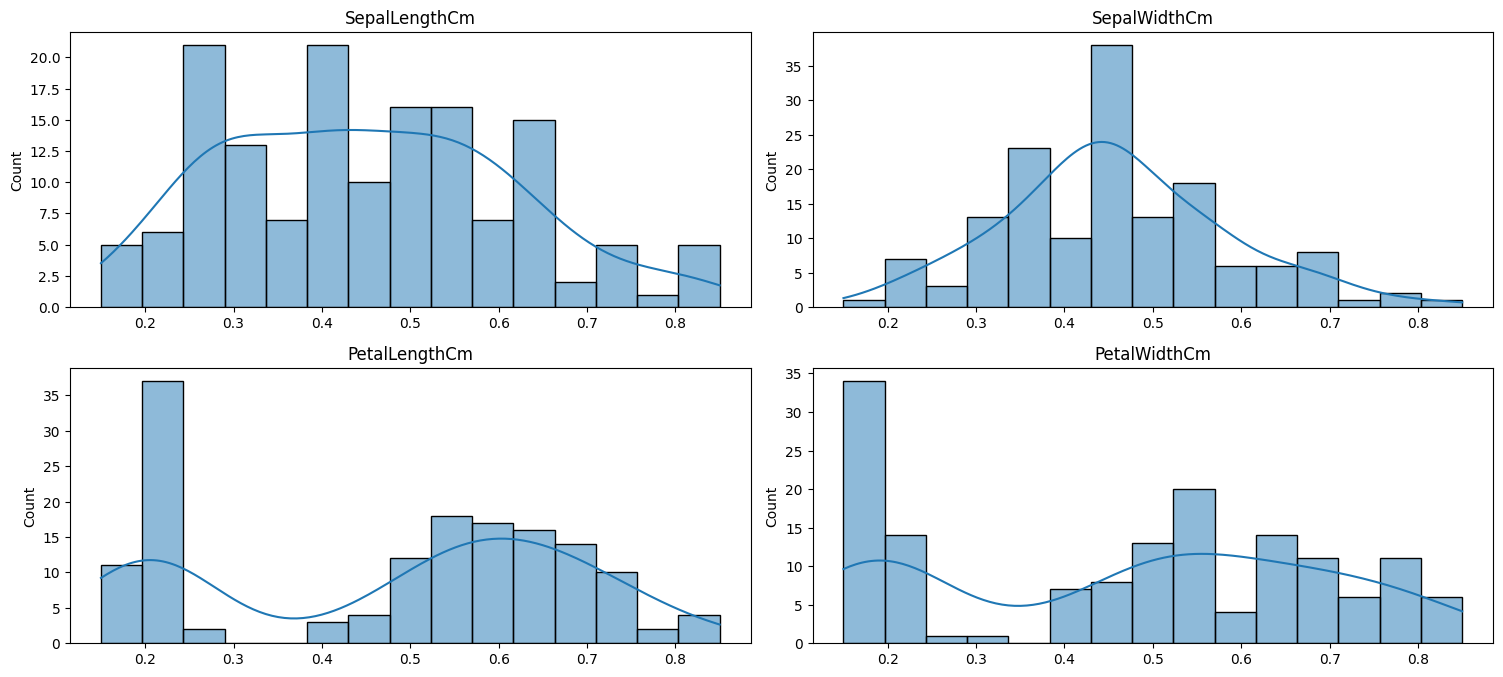

In [32]:
train_data_np = train_data_df.to_numpy()
min_val = train_data_np.min(axis=0)
max_val = train_data_np.max(axis=0)

# range_l ~ range_r 범위로 rescale
rescaled = range_l + (train_data_np - min_val) / (max_val - min_val) * (range_r - range_l)

plt.figure(figsize=(15, 10))
for i, col in enumerate(train_data_df.columns):
    plt.subplot(math.ceil(len(numeric_cols) / 2), 2, i + 1)
    sns.histplot(rescaled[:, i], kde=True, bins=15)
    plt.title(col)
plt.tight_layout()
plt.show()

train_tensor = torch.tensor(rescaled, dtype=torch.float32)

In [34]:
# setting torch device
ml_device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
quantum_device = qml.device("default.qubit", wires=n_qubits)
print("고전 머신러닝 device =", ml_device, "양자 회로 backend =", quantum_device)

# 생성자 파라미터 초기화 및 모듈 불러오기
generator_initial_params = Variable(torch.tensor(np.random.normal(-np.pi , np.pi, (n_layers, n_qubits, 1))), requires_grad=True)
generator = QGAN.QGAN2(n_qubits, output_qubits, n_layers, generator_initial_params, quantum_device)

# 판별자, MINE 초기화
discriminator = Discriminator.LinearDiscriminator(input_dim = output_qubits, hidden_size=128)
mine = MINE.LinearMine(code_dim=code_qubits, output_dim=output_qubits)

G_opt = torch.optim.Adam([generator.params], lr=G_lr)
D_opt = torch.optim.Adam(discriminator.parameters(), lr=D_lr)
M_opt = torch.optim.Adam(mine.parameters(), lr=M_lr)

고전 머신러닝 device = cpu 양자 회로 backend = <default.qubit device (wires=6) at 0x23260b36560>
